# **Intersectional Bias Detection and Mitigation System in Intelligent Systems**

---




## Ciao Prolog and External Libraries Installation
This section is responsible for configuring the environment for the bias detection and mitigation system, specifically installing Ciao Prolog, which will be used as the declarative logic engine for selecting mitigation techniques. The process includes:

- Cleaning the environment of previous installations

- Installing system dependencies

- Downloading and compiling Ciao Prolog from the official repository

- Verifying the installation

- Installing additional libraries required for the project

In [37]:
# Clean up previous installations to avoid conflicts
!rm -rf ciao-master master.zip

# System update and installation of essential dependencies
# > /dev/null 2>&1 redirects output to keep the notebook clean
!apt-get update > /dev/null 2>&1
!apt-get install -y build-essential wget curl > /dev/null 2>&1

print("Installing Ciao Prolog...")

# Download Ciao Prolog source code from GitHub
!wget -q https://github.com/ciao-lang/ciao/archive/refs/heads/master.zip

# Extract the compressed file
!unzip -q -o master.zip

# Compile and install Ciao Prolog
# This process may take several minutes
!cd ciao-master && ./ciao-boot.sh local-install --with-eng=ciaoengine

# Verify installation - we look for the ciaosh executable
!find ciao-master -name "ciaosh" -type f 2>/dev/null | head -5

# Install imbalanced-learn if not available
# This library is essential for bias mitigation techniques
try:
    import imblearn
    print("imbalanced-learn is already installed")
except Exception:
    print("Installing imbalanced-learn...")
    !pip install -q imbalanced-learn
    import imblearn

print("Environment setup completed successfully")

Installing Ciao Prolog...
=> builder: building [boot]
   compiling ciaoengine (engine for ciaoc.sta)
   compiling ciao_builder (command) [using ciaoc.sta]
   reusing ciaoengine (engine for ciao_builder)
{WARNING (bundle_configure): Unknown configuration flag `builder:with_eng'}
   Configuration mode... basic
   Verbose builder... no
   Generate documentation... yes
   Generate .asr files during compilation... yes
   Enable parallel builds (experimental)... no
   Installation type... local
   Registration type... user
   Prefix for installation directories... 
   Base for system installation... 
   Installation directory for executables... 
   Installation directory for 'man' pages... 
   Installation directory for 'info' files... 
   Permissions for installed execs/dirs... 775
   Permissions for installed data files... 664
   Custom group for installed files... 
   Path of GNU make command... /usr/bin/gmake
   Path of GNU tar command... /usr/bin/tar
   Update dot shell initialization f

## Library Imports

This code block imports all the necessary libraries and modules for the implementation of the bias detection and mitigation system. The libraries are organized into the following categories:

- System and temporal handling: For temporary file management and process execution

- Data processing: For data manipulation and analysis

- Machine Learning: For models, preprocessing, and evaluation

- Visualization: For charts and visual representations

- Data balancing: For bias mitigation techniques

- IPython utilities: To improve presentation in notebooks

In [38]:
# --- System libraries and temporary file handling ---
import tempfile  # To create temporary files and directories
import os        # To interact with the operating system
import subprocess  # To execute system commands
import time       # To handle time-related operations

# --- Data processing and numerical arrays ---
import numpy as np    # For numerical operations and arrays
import pandas as pd   # For manipulation and analysis of tabular data

# --- Typing and utilities ---
from typing import Dict, Any, List  # For type annotations
from itertools import product  # To generate Cartesian products
from abc import ABC, abstractmethod  # For abstract base classes and abstract methods

# --- IPython utilities for notebooks ---
from IPython.display import clear_output, display  # To clear and display output

# --- Machine Learning: Datasets and preprocessing ---
from sklearn.datasets import fetch_openml  # To download datasets from OpenML
from sklearn.preprocessing import StandardScaler, OneHotEncoder  # Scaling and encoding
from sklearn.linear_model import LogisticRegression  # Logistic regression model
from sklearn.metrics import accuracy_score, f1_score  # Evaluation metrics
from sklearn.pipeline import Pipeline  # To create ML pipelines

# --- Data balancing techniques (bias mitigation) ---
from imblearn.over_sampling import RandomOverSampler, SMOTE  # Oversampling
from imblearn.under_sampling import RandomUnderSampler # Undersampling

# --- Additional Machine Learning models ---
from sklearn.ensemble import RandomForestClassifier  # Random Forest model
from sklearn.model_selection import train_test_split  # Train/test split

# --- Feature engineering ---
from sklearn.preprocessing import PolynomialFeatures  # For polynomial features

# --- Data visualization ---
import matplotlib.pyplot as plt  # To create charts
import seaborn as sns            # For statistical visualizations

# --- Date and JSON handling ---
from datetime import datetime    # For date and time handling
import json                      # For JSON data manipulation

## Configuration and Data Handling
This section defines the fundamental classes for system configuration and data management. Global parameters are set, the loading and preparation of the COMPAS dataset are implemented, and the training of the base model that will be monitored in production is configured.

- **Global System Configuration:** The Config class centralizes all critical system parameters and thresholds, facilitating maintenance and consistency across all bias detection and mitigation phases.

- **Data Loading and Preparation:** The DataLoader class is responsible for obtaining the dataset from its original source, performing necessary cleaning, and creating intersectional groups that are essential for fairness analysis.

- **Base Model Training:** The ModelTrainer class implements the training pipeline for the model that will be deployed in production and subsequently monitored to detect intersectional biases.

In [39]:
class Config:
    """
    Global System Configuration.

    This class stores all parameters, thresholds, and constants used
    throughout the bias detection and mitigation system.

    Attributes:
        SPD_THRESHOLD (float): Threshold for Statistical Parity Difference.
                               Absolute values > 0.1 indicate significant disparity.
        DI_THRESHOLD (float): Threshold for Disparate Impact.
                              Values < 0.8 indicate adverse impact (80% rule).
        EOD_THRESHOLD (float): Threshold for Equal Opportunity Difference.
                               Absolute values > 0.1 indicate disparity in TPR.
        HFI_THRESHOLD (float): Threshold for Harmonic Fairness Intersectional.
                               Values < 0.8 indicate insufficient global fairness.
        PREDICTION_BUFFER_SIZE (int): Buffer size for real-time metric calculation.
        MONITORING_BATCH_SIZE (int): Metric calculation frequency (every n predictions).
        CIAO_PATH (str): Path to the Ciao Prolog executable for the decision engine.
    """
    SPD_THRESHOLD = 0.1
    DI_THRESHOLD = 0.8
    EOD_THRESHOLD = 0.1
    HFI_THRESHOLD = 0.8
    PREDICTION_BUFFER_SIZE = 150
    MONITORING_BATCH_SIZE = 150
    CIAO_PATH = "ciao-master/build/bin/ciaosh"

    # WEIGHTS FOR THE FINAL UTILITY FUNCTION:
    # Utility = (PS * WEIGHT_PS) + (HFI * WEIGHT_HFI)
    UTILITY_WEIGHT_PS = 0.3  # Weight of the Performance Component (PS) in the Final Utility
    UTILITY_WEIGHT_HFI = 0.7 # Weight of the Fairness Component (HFI) in the Final Utility

    # WEIGHTS FOR THE PERFORMANCE SCORE (PS):
    # PS = (F1 * WEIGHT_F1) + (Accuracy * WEIGHT_ACC)
    PS_WEIGHT_F1 = 0.7       # Weight of the F1-score in the Performance Score
    PS_WEIGHT_ACC = 0.3      # Weight of the Accuracy in the Performance Score

class DataLoader:
    """Loads, cleans, and prepares the COMPAS dataset for bias analysis."""

    @staticmethod
    def load_compas_data():
        """
        Loads the COMPAS dataset and creates a multiclass classification of criminal risk:
        Low / Medium / High.

        It also creates the intersectional group by race and sex.
        """

        # COMPAS dataset (version commonly used in fairness research)
        url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"

        df = pd.read_csv(url)

        # Working copy
        df_clean = df.copy()

        # ----------------------------------------------------------
        # 1. Create the multiclass target variable
        # ----------------------------------------------------------
        # We use the original variable: "decile_score" (0–10)
        # Typical conventions in literature:
        #   1–3  -> Low
        #   4–6  -> Medium
        #   7–10 -> High

        def map_risk(decile):
            if decile <= 3:
                return "Low"
            elif decile <= 6:
                return "Medium"
            else:
                return "High"

        df_clean["risk_level"] = df_clean["decile_score"].apply(map_risk)

        # ----------------------------------------------------------
        # 2. Create intersectional groups: race + sex
        # ----------------------------------------------------------
        # Variables already present in COMPAS: race, sex
        df_clean["intersectional_group"] = df_clean["race"] + "_" + df_clean["sex"]

        # ----------------------------------------------------------
        # 3. Remove rows with missing values in critical columns
        # ----------------------------------------------------------
        required_cols = ["decile_score", "race", "sex"]
        df_clean = df_clean.dropna(subset=required_cols)

        return df_clean

    @staticmethod
    def prepare_features_compas(df):
        """
        Selects and prepares the numerical features of the COMPAS dataset
        for the machine learning model.

        Args:
            df (pandas.DataFrame): Cleaned dataset with all columns.

        Returns:
            tuple: (X, Y) where:
                - X are the selected numerical features.
                - Y is the multiclass target variable (Low / Medium / High).

        Note:
            Relevant numerical features are selected for simplification,
            following the same philosophy as in Adult and German.
        """

        # Selection of relevant numerical features for COMPAS
        features = [
            'age',
            'priors_count',
            'juv_fel_count',
            'juv_misd_count',
            'juv_other_count'
        ]

        # Filter the necessary columns (only numerical)
        X = df[features]

        # Multiclass target variable created previously
        Y = df['risk_level']

        return X, Y

class ModelTrainer:
    """Trains and evaluates the base model that will be monitored in production."""

    def train_production_model(self, X, y, test_size=0.3, random_state=42):
        """
        Trains a Random Forest model as a base system in production.

        Args:
            X (pandas.DataFrame): Model features.
            y (pandas.Series): Target variable.
            test_size (float): Proportion of the dataset for testing.
            random_state (int): Seed for reproducibility.

        Returns:
            tuple: (model, X_train, X_test, y_train, y_test)
                   - model: Trained Random Forest model
                   - X_train, y_train: Training data
                   - X_test, y_test: Testing data

        Note:
            Random Forest is selected for its robustness and good performance on tabular data.
        """
        # Stratified train/test split
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, random_state=random_state
        )

        # Configuration and training of the Random Forest model
        model = RandomForestClassifier(n_estimators=200, random_state=65)
        model.fit(X_train, y_train)

        # Base model evaluation
        test_accuracy = model.score(X_test, y_test)
        print(f"Model trained - Accuracy: {test_accuracy:.3f}")

        return model, X_train, X_test, y_train, y_test

## Bias Detection Module
This module implements the core functionality for real-time monitoring of intersectional biases in the model's predictions. It contains two main classes: BiasMetricsCalculator for calculating fairness metrics and RealTimeBiasMonitor for continuous monitoring and alert detection.

### Intersectional Fairness Metrics

The system calculates four fundamental metrics to evaluate fairness from an intersectional perspective:

- SPD (Statistical Parity Difference): Measures differences in positive prediction rates

- DI (Disparate Impact): Evaluates relative impact between groups using the 80% rule

- EOD (Equal Opportunity Difference): Analyzes disparities in true positive rates

- HFI (Intersectional Harmonic Fairness): Provides an aggregated measure of global fairness

### BiasMetricsCalculator
Intersectional fairness metrics calculator. This class implements the mathematical formulas to measure different dimensions of fairness in groups defined by intersections of sensitive attributes.

### Responsibilities
- Calculate statistical fairness metrics for intersectional groups
- Handle edge cases and extreme values robustly
- Provide both individual and aggregated measures of fairness

### Main Methods
- `calculate_spd`: Calculates Statistical Parity Difference (SPD)
- `calculate_di`: Calculates Disparate Impact (DI)
- `calculate_eod`: Calculates Equal Opportunity Difference (EOD)
- `calculate_hfi`: Calculates Intersectional Harmonic Fairness (HFI)

In [40]:
class BiasMetricsCalculator:
    """
    Metrics adapted to multiclass:
    - SPD: macro-average across classes of (P(pred=cls|G=g) - P(pred=cls|G!=g))
    - DI: macro-average across classes of (P(pred=cls|G=g) / P(pred=cls|G!=g))
    - EOD: macro-average across classes of (TPR_group(cls) - TPR_others(cls))
    - HFI: harmonic fairness intersectional (relies on DI values)
    """

    @staticmethod
    def calculate_spd_multiclass(group_data: pd.DataFrame, other_data: pd.DataFrame):
        """
        Corrected version: Returns the SIGNED difference of the class with the highest absolute disparity.
        """
        classes = np.union1d(group_data['prediction'].unique(), other_data['prediction'].unique())
        max_spd_val = 0.0 # Store the signed value
        max_abs_spd = 0.0 # Store the absolute magnitude to compare

        for cls in classes:
            p_group = (group_data['prediction'] == cls).mean() if len(group_data) > 0 else 0.0
            p_other = (other_data['prediction'] == cls).mean() if len(other_data) > 0 else 0.0

            diff = p_group - p_other # Signed difference
            abs_diff = abs(diff)

            # If we find a larger disparity, we store it
            if abs_diff > max_abs_spd:
                max_abs_spd = abs_diff
                max_spd_val = diff

        return max_spd_val

    @staticmethod
    def calculate_di_multiclass(group_data: pd.DataFrame, other_data: pd.DataFrame):
        classes = np.union1d(group_data['prediction'].unique(), other_data['prediction'].unique())
        di_values = []
        for cls in classes:
            p_group = (group_data['prediction'] == cls).mean() if len(group_data) > 0 else 0.0
            p_other = (other_data['prediction'] == cls).mean() if len(other_data) > 0 else 0.0
            if p_other > 0:
                di_values.append(p_group / p_other)
        # If no valid di values, return 1.0 (neutral)
        return float(np.mean(di_values)) if di_values else 1.0

    @staticmethod
    def calculate_eod_multiclass(group_data: pd.DataFrame, other_data: pd.DataFrame):
        # Use actual labels to compute TPR per class
        classes = np.union1d(group_data['actual'].unique(), other_data['actual'].unique())
        eod_values = []
        for cls in classes:
            g_pos = group_data[group_data['actual'] == cls]
            o_pos = other_data[other_data['actual'] == cls]
            if len(g_pos) == 0 or len(o_pos) == 0:
                continue
            tpr_group = (g_pos['prediction'] == cls).mean()
            tpr_other = (o_pos['prediction'] == cls).mean()
            eod_values.append(tpr_group - tpr_other)
        return float(np.mean(eod_values)) if eod_values else 0.0

    @staticmethod
    def calculate_hfi_multiclass(metrics: Dict[str, Dict[str, Any]]):
        """
        metrics: dict per group -> dict containing {'DI': value, ...}
        HFI = n / sum(1 / fairness_i) where fairness_i = min(DI, 1/DI)
        """
        fairness_values = []
        for g, m in metrics.items():
            di = m.get('DI')
            if di is None or di <= 0 or np.isinf(di) or np.isnan(di):
                continue
            fairness = min(di, 1.0 / di)
            if fairness > 0:
                fairness_values.append(fairness)
        if not fairness_values:
            return 1.0
        inv_sum = sum(1.0 / f for f in fairness_values)
        return float(len(fairness_values) / inv_sum) if inv_sum > 0 else 1.0

### RealTimeBiasMonitor
Real-time monitoring system for intersectional bias detection. This class simulates a production environment where predictions are continuously ingested, fairness metrics are calculated, and alerts are generated when biases are detected.

### Responsibilities
- Manage sliding buffer of recent predictions
- Calculate fairness metrics periodically
- Detect and classify different types of biases
- Generate explanatory alerts with context

### System Components
- **Prediction Buffer**: Temporary storage of predictions for analysis
- **Metrics Calculator**: Fairness metrics calculation engine
- **Alert Engine**: Bias detection and classification system

### Main Methods
- `__init__`: Initializes the monitor with model and sensitive attributes
- `ingest_prediction`: Ingests a new prediction into the monitoring buffer
- `calculate_intersectional_metrics`: Calculates metrics for all intersectional groups
- `detect_bias_alerts`: Detects and classifies biases based on calculated metrics

In [41]:
class RealTimeBiasMonitor:
    """
    Real-time monitoring system for intersectional bias detection.

    This class simulates a production environment where predictions are continuously
    ingested, fairness metrics are calculated, and alerts are generated when biases are detected.
    """
    def __init__(self, model, intersectional_features: List[str]):
        self.model = model
        self.intersectional_features = intersectional_features
        self.prediction_buffer = []
        self.metrics_calculator = BiasMetricsCalculator()

    def ingest_prediction(self, features: pd.DataFrame, sensitive_attributes: dict, actual_outcome):
        """
        Ingests a new prediction into the monitoring buffer.

        Args:
            features: DataFrame with a single row (index preserved)
            sensitive_attributes: dict of feature->value e.g. {'race': 'African-American', 'sex': 'Male'}
            actual_outcome: actual class label string (or None if unknown)
        """
        pred = self.model.predict(features)[0]
        probas = self.model.predict_proba(features)[0] if hasattr(self.model, "predict_proba") else None

        record = {
            'sensitive_attributes': sensitive_attributes,
            'prediction': pred,
            'probabilities': probas,
            'actual': actual_outcome
        }

        self.prediction_buffer.append(record)
        if len(self.prediction_buffer) > Config.PREDICTION_BUFFER_SIZE:
            self.prediction_buffer.pop(0)

    def calculate_intersectional_metrics(self):
        if len(self.prediction_buffer) < 100:
            print(f"Buffer insufficient: {len(self.prediction_buffer)} < 100")
            return None

        monitor_data = []
        for pred in self.prediction_buffer:
            if pred['actual'] is not None:
                group_name = '_'.join([str(pred['sensitive_attributes'].get(f, 'NA')) for f in self.intersectional_features])
                monitor_data.append({
                    'intersectional_group': group_name,
                    'prediction': pred['prediction'],
                    'actual': pred['actual']
                })

        if not monitor_data:
            return None

        monitor_df = pd.DataFrame(monitor_data)
        print(f"Buffer size: {len(self.prediction_buffer)}")
        print(f"Data valid for analysis: {len(monitor_data)}")
        print(f"Unique groups found: {len(monitor_df['intersectional_group'].unique())}")
        results = {}
        for group in monitor_df['intersectional_group'].unique():
            group_data = monitor_df[monitor_df['intersectional_group'] == group]
            other_data = monitor_df[monitor_df['intersectional_group'] != group]
            if len(group_data) > 5 and len(other_data) > 5:
                spd = self.metrics_calculator.calculate_spd_multiclass(group_data, other_data)
                di = self.metrics_calculator.calculate_di_multiclass(group_data, other_data)
                eod = self.metrics_calculator.calculate_eod_multiclass(group_data, other_data)
                results[group] = {
                    'SPD': spd,
                    'DI': di,
                    'EOD': eod,
                    'representation': len(group_data) / len(monitor_df)
                }

        hfi_global = None
        if results:
            hfi_global = self.metrics_calculator.calculate_hfi_multiclass(results)

        return {
            "groups": results,
            "HFI_global": hfi_global
        }

    def detect_bias_alerts(self, metrics):
        alerts = []
        if metrics is None:
            print("No metrics to analyze")
            return alerts

        print(f"Processing bias detection with available metrics")

        def severity_level(delta):
            if delta < 0.50:
                return "LOW"
            elif delta < 1.50:
                return "MEDIUM"
            else:
                return "HIGH"

        hfi_value = metrics.get("HFI_global", 1.0)
        group_metrics = metrics.get("groups", {})

        print(f"Global HFI: {hfi_value:.3f} (threshold: {Config.HFI_THRESHOLD})")
        print(f"Groups to analyze: {len(group_metrics)}")

        if hfi_value < Config.HFI_THRESHOLD:
            delta = abs(Config.HFI_THRESHOLD - hfi_value) / Config.HFI_THRESHOLD
            alerts.append({
                'group': 'GLOBAL',
                'bias_type': 'Selection Bias',
                'metric': 'HFI',
                'value': hfi_value,
                'threshold': Config.HFI_THRESHOLD,
                'severity': severity_level(delta)
            })

        for group, m in group_metrics.items():
            # SPD
            if abs(m['SPD']) > Config.SPD_THRESHOLD:
                spd_delta = abs(abs(m['SPD']) - Config.SPD_THRESHOLD) / max(Config.SPD_THRESHOLD, 1e-9)
                alerts.append({
                    'group': group,
                    'bias_type': 'Representation Bias',
                    'metric': 'Statistical Parity',
                    'value': m['SPD'],
                    'threshold': Config.SPD_THRESHOLD,
                    'severity': severity_level(spd_delta)
                })

            # DI
            if m['DI'] < Config.DI_THRESHOLD and m['representation'] >= 0.05:
                di_delta = abs(Config.DI_THRESHOLD - m['DI']) / max(Config.DI_THRESHOLD, 1e-9)
                alerts.append({
                    'group': group,
                    'bias_type': 'Historical Bias',
                    'metric': 'Disparate Impact',
                    'value': m['DI'],
                    'threshold': Config.DI_THRESHOLD,
                    'severity': severity_level(di_delta)
                })

            # Representation small
            if m['representation'] < 0.03:
                rep_delta = abs(0.03 - m['representation']) / 0.03
                alerts.append({
                    'group': group,
                    'bias_type': 'Exclusion Bias',
                    'metric': 'Group Representation',
                    'value': m['representation'],
                    'threshold': 0.05,
                    'severity': severity_level(rep_delta)
                })

            # EOD
            if m['EOD'] is not None and abs(m['EOD']) > Config.EOD_THRESHOLD:
                eod_delta = abs(abs(m['EOD']) - Config.EOD_THRESHOLD) / max(Config.EOD_THRESHOLD, 1e-9)
                alerts.append({
                    'group': group,
                    'bias_type': 'Measurement Bias',
                    'metric': 'Equal Opportunity',
                    'value': m['EOD'],
                    'threshold': Config.EOD_THRESHOLD,
                    'severity': severity_level(eod_delta)
                })

        return alerts

## Mitigation Technique Decision Module
This module implements the decision-making system to automatically select the most suitable mitigation techniques based on the detected biases. It uses Ciao Prolog as a declarative logic engine that emulates human expert reasoning, combined with a Python interface for integration with the rest of the system.

### Decision System Architecture
The module follows a hybrid approach where:

- Ciao Prolog handles complex selection rules based on bias types, severity, and metrics

- Python provides the integration interface and fallback handling

- Decisions are prioritized according to criticality and the type of detected bias

### CiaoPrologEngine
Mitigation decision engine using Ciao Prolog. This class manages communication with the Prolog engine that contains expert rules for selecting optimal mitigation techniques.

### Responsibilities
- Configure and write the Prolog module with decision rules
- Execute Prolog queries securely with error handling
- Process lists of alerts and return recommended mitigation techniques

### Main Methods
- `__init__`: Initializes the Prolog engine with the configuration path
- `setup_prolog_module`: Configures and writes the Prolog module with decision rules
- `execute_query_clean`: Executes a Prolog query securely with error handling
- `process_mitigation_alerts`: Processes a list of alerts and returns the recommended mitigation techniques

In [42]:
class CiaoPrologEngine:
    """
    Mitigation decision engine using Ciao Prolog - IMPROVED
    Maintains compatibility with your current system
    """

    def __init__(self):
        """Initializes the Prolog engine."""
        self.ciao_path = Config.CIAO_PATH
        self.setup_prolog_module()
        self._verify_ciao_availability()

    def _verify_ciao_availability(self):
        """Verifies that Ciao Prolog is available """
        if not os.path.exists(self.ciao_path):
            # Try to find alternative executable
            alternative_paths = [
                "ciao-master/build/bin/ciaosh",
                "./ciao-master/build/bin/ciaosh",
                "ciaosh",
                "/usr/local/bin/ciaosh",
                "/usr/bin/ciaosh"
            ]
            for path in alternative_paths:
                if os.path.exists(path):
                    self.ciao_path = path
                    print(f"Ciao Prolog found at: {path}")
                    return

            print("Ciao Prolog not available - fallback mode activated")
            self.ciao_path = None
        else:
            print(f"Ciao Prolog verified at: {self.ciao_path}")

    def setup_prolog_module(self):
        """
        Configures the Prolog module with IMPROVED v2 rules
        while maintaining compatibility
        """
        prolog_code = """
:- module(mitigation_selector, [process_alerts/2, select_technique/2]).
:- use_module(library(lists)).
:- use_module(library(aggregates)).

% ============================================================
% 1. KNOWLEDGE BASE
% ============================================================

% Phase definition (Pipeline)
technique_phase(resampling,                     pre).
technique_phase(reweighting,                    pre).
technique_phase(feature_augmentation,           in).
technique_phase(nsga_ii,                        in).
technique_phase(heuristic_threshold_adjustment, post).

% Base technique strength (Higher = more aggressive)
technique_strength(resampling,                     11).
technique_strength(reweighting,                    5).
technique_strength(nsga_ii,                        5).
technique_strength(feature_augmentation,           10).
technique_strength(heuristic_threshold_adjustment, 5).

% Severity multipliers
severity_weight(critical, 4).
severity_weight(high,     3).
severity_weight(medium,   2).
severity_weight(low,      1).

% ============================================================
% 2. MAPPING RULES (Alert -> Technique)
% ============================================================

% -- Representation Bias --
select_technique(alert(representation, _, _, Severity), resampling) :-
    (Severity = critical ; Severity = high).
select_technique(alert(representation, _, _, Severity), reweighting) :-
    (Severity = medium ; Severity = low).

% -- Selection Bias --
select_technique(alert(selection, _, _, _), resampling).

% -- Measurement Bias --
select_technique(alert(measurement, _, _, high), nsga_ii).
select_technique(alert(measurement, _, _, critical), nsga_ii).
select_technique(alert(measurement, _, _, medium), feature_augmentation).
select_technique(alert(measurement, _, _, low), feature_augmentation).

% -- Historical Bias --
select_technique(alert(historical, _, _, critical), feature_augmentation).
select_technique(alert(historical, _, _, high), feature_augmentation).
select_technique(alert(historical, _, _, _), heuristic_threshold_adjustment).

% -- Feature Exclusion Bias --
select_technique(alert(feature_exclusion, _, _, _), feature_augmentation).

% -- General Fallback --
select_technique(alert(_, _, _, critical), resampling).

% ============================================================
% 3. MAIN LOGIC
% ============================================================

process_alerts(Alerts, FinalTechniques) :-
    % 1. Find candidates with calculated weights
    findall(candidate(Phase, Tech, Weight),
            (member(Alert, Alerts),
             calculate_candidate_weight(Alert, Phase, Tech, Weight)),
            Candidates),

    % 2. Optimize pipeline (choose best per phase)
    optimize_pipeline(Candidates, SelectedLists),

    % 3. Flatten list of lists to a simple list
    flatten_techniques(SelectedLists, FinalTechniques).

% Calculate weight: Technique strength * Alert severity
calculate_candidate_weight(Alert, Phase, Tech, TotalWeight) :-
    Alert = alert(_, _, _, Severity),
    select_technique(Alert, Tech),
    technique_phase(Tech, Phase),
    technique_strength(Tech, BaseStr),
    severity_weight(Severity, SevMult),
    TotalWeight is BaseStr * SevMult.

% ============================================================
% 4. PIPELINE OPTIMIZATION
% ============================================================

optimize_pipeline(Candidates, Pipeline) :-
    select_best_in_phase(Candidates, pre, PreTech),
    select_best_in_phase(Candidates, in, InTech),
    select_best_in_phase(Candidates, post, PostTech),
    % Construct list with results (can be empty)
    Pipeline = [PreTech, InTech, PostTech].

% Select the best candidate for a phase
select_best_in_phase(Candidates, TargetPhase, [BestTech]) :-
    % Filter candidates of this phase
    findall(w(W, T),
            member(candidate(TargetPhase, T, W), Candidates),
            PhaseCandidates),
    PhaseCandidates \= [], % Ensure there are candidates
    % Sort to find maximum weight
    % sort/2 sorts ascending, reverse makes it descending
    sort(PhaseCandidates, Sorted),
    reverse(Sorted, [w(_, BestTech)|_]), !.

% If no candidates, return empty list
select_best_in_phase(_, _, []).

% ============================================================
% 5. UTILITIES
% ============================================================

% Flatten list of lists and remove duplicates (manual to avoid dependencies)
flatten_techniques([], []).
flatten_techniques([[]|T], Rest) :- !, flatten_techniques(T, Rest).
flatten_techniques([[X]|T], [X|Rest]) :- !, flatten_techniques(T, Rest).
flatten_techniques([H|T], [H|Rest]) :- atom(H), !, flatten_techniques(T, Rest).
"""
        # Write Prolog code to file for execution
        try:
            with open('mitigation_selector.pl', 'w') as f:
                f.write(prolog_code)
            # Verify file was created
            if os.path.exists('mitigation_selector.pl'):
                print("Prolog file verified")
            else:
                print("Error: Prolog file was not created")

        except Exception as e:
            print(f"Error creating Prolog file: {e}")

    def execute_query_clean(self, query):
        """
        Executes Prolog query
        """
        # Verify availability of Ciao Prolog
        if self.ciao_path is None:
            print("Ciao Prolog not available, using fallback")
            return False, "Ciao Prolog not available", None

        # Create temporary script IMPROVED
        with tempfile.NamedTemporaryFile(mode='w', suffix='.pl', delete=False) as f:
            script_path = f.name
            print(f"Executing Prolog query: {query}")
            f.write("use_module(mitigation_selector).\n")  # Load module
            f.write(f"{query}.\n")  # Execute query
            f.write("halt.\n")  # Terminate execution

        try:
            # Execute query with timeout
            cmd = f"cat {script_path} | {self.ciao_path} -q 2>/dev/null"
            result = subprocess.run(
                cmd, shell=True, capture_output=True, text=True, timeout=8
            )

            # Process output IMPROVED
            output = result.stdout.strip()
            success = result.returncode == 0
            print(f"Prolog output: '{output}'")
            print(f"Success: {success}, Return code: {result.returncode}")

            if success and output:
                # Search for techniques in output
                techniques = self._extract_techniques_from_output(output)
                if techniques:
                    return True, output, techniques
                else:
                    if "UniqueTechniques =" in output:
                        response = output.split("UniqueTechniques = ")[-1].replace(" ;", "").replace(".", "").strip()
                        return True, output, response

            return False, output, None

        except subprocess.TimeoutExpired:
            print(" Timeout in Prolog query")
            return False, "Query timed out", None
        except Exception as e:
            print(f"Error executing Prolog: {e}")
            return False, str(e), None
        finally:
            try:
                os.remove(script_path)
            except:
                pass

    def _extract_techniques_from_output(self, output):
        """
        Extraction of techniques from output
        """
        techniques = []

        if 'reweighting' in output:
            techniques.append('reweighting')
        if 'resampling' in output:
            techniques.append('resampling')
        if 'nsga_ii' in output:
            techniques.append('nsga_ii')
        if 'heuristic_threshold_adjustment' in output:
            techniques.append('heuristic_threshold_adjustment')
        if 'feature_augmentation' in output:
            techniques.append('feature_augmentation')

        return techniques if techniques else None

    def process_mitigation_alerts(self, prolog_alerts):
        """
        Process alerts
        """
        # Build Prolog query
        print(f"Processing {len(prolog_alerts)} alerts with Ciao Prolog")

        # Execute query
        query = f"process_alerts([{', '.join(prolog_alerts)}], UniqueTechniques)" # <-- Added this line for query definition
        success, raw_output, response = self.execute_query_clean(query)

        if success and response:
            try:
                if isinstance(response, list):
                    return response
                else:
                    techniques = [t.strip() for t in response.strip('[]').split(',') if t.strip()]
                    return self._validate_technique_diversity(techniques)
            except Exception as e:
                print(f"Error processing response: {e}")
                return []

        print("Ciao Prolog engine failed, using fallback")
        return []  # Empty list if no techniques selected

    def _validate_technique_diversity(self, techniques):
        """
        Validation
        """
        if not techniques:
            return techniques

        print(f"Validating")

        # Sort by mitigation phase
        phase_order = {
            'resampling': 1,    # Pre-processing
            'reweighting': 1,   # Pre-processing
            'nsga_ii': 2,       # In-processing
            'feature_augmentation': 2,  # In-processing
            'heuristic_threshold_adjustment': 3   # Post-processing
        }

        # Filter: maximum 1 technique per phase
        techniques_by_phase = {}
        for tech in techniques:
            phase = phase_order.get(tech, 1)
            if phase not in techniques_by_phase:
                techniques_by_phase[phase] = tech

        filtered_techniques = list(techniques_by_phase.values())
        print(f"Validated techniques: {filtered_techniques}")
        return filtered_techniques

<>:142: SyntaxWarning: invalid escape sequence '\='
<>:142: SyntaxWarning: invalid escape sequence '\='
/tmp/ipykernel_17845/772127386.py:142: SyntaxWarning: invalid escape sequence '\='
  PhaseCandidates \= [], % Ensure there are candidates


### MitigationSelector
Python interface for the mitigation decision engine. This class acts as a bridge between the Python system and the Prolog engine, translating Python alerts to Prolog format and handling fallbacks.

### Responsibilities
- Convert Python alerts to Prolog format for processing
- Select mitigation techniques based on detected alerts
- Provide fallback logic when the Prolog engine is unavailable

### Main Methods
- `__init__`: Initializes the selector with the Prolog engine
- `python_to_prolog_alerts`: Converts Python alerts to Prolog format for processing
- `select_mitigation`: Selects mitigation techniques based on detected alerts

In [43]:
class MitigationSelector:
    """
    Python interface for the mitigation decision engine
    """

    def __init__(self):
        """Initializes the selector ."""
        self.ciao_engine = CiaoPrologEngine()
        self.fallback_count = 0  # New: fallback counter
        self.decision_history = []  # New: decision history

    def python_to_prolog_alerts(self, alerts):
        """
        Converts Python alerts to Prolog format
        """
        prolog_alerts = []

        # mappings for more robust conversion
        bias_type_map = {
            'Representation Bias': 'representation',
            'Historical Bias': 'historical',
            'Measurement Bias': 'measurement',
            'Selection Bias': 'selection',
            'Feature Exclusion Bias': 'feature_exclusion'
        }

        severity_map = {
            'LOW': 'low', 'MEDIUM': 'medium', 'HIGH': 'high', 'CRITICAL': 'critical'
        }

        metric_map = {
            'Statistical Parity': 'spd',
            'Disparate Impact': 'di',
            'Equal Opportunity': 'eod',
            'Historical Fairness Index': 'hfi'
        }

        for alert in alerts:
            try:
                # Normalization
                original_bias_type = alert['bias_type']
                bt = bias_type_map.get(original_bias_type,
                                    original_bias_type.split()[0].lower().replace('_', ''))

                # Severity
                severity = severity_map.get(alert['severity'],
                                          alert['severity'].lower())

                # Metric
                original_metric = alert['metric']
                metric = metric_map.get(original_metric,
                                      original_metric.lower().split()[-1])

                # Group (cleaned for safety)
                group = alert['group'].replace("'", "").replace('"', '')[:50]

                # Construct Prolog term (original format)
                prolog_term = f"alert({bt}, '{group}', [{metric}], {severity})"
                prolog_alerts.append(prolog_term)

            except Exception as e:
                print(f"Error converting alert: {e}")
                # Fallback to original method
                bt = alert['bias_type'].split()[0].lower().replace('_', '')
                severity = alert['severity'].lower()
                metric = alert['metric'].lower().split()[-1]
                prolog_term = f"alert({bt}, '{alert['group']}', [{metric}], {severity})"
                prolog_alerts.append(prolog_term)

        print(f"Converted {len(prolog_alerts)} alerts to Prolog")
        return prolog_alerts

    def select_mitigation(self, alerts):
        """
        Selects mitigation techniques - ORIGINAL INTERFACE
        but with IMPROVED internal logic
        """
        # Case without alerts (original behavior)
        if not alerts:
            print("No alerts, using default technique")
            return ['feature_augmentation']

        print(f"Selecting mitigation for {len(alerts)} alerts...")

        # Convert alerts to Prolog format
        prolog_alerts = self.python_to_prolog_alerts(alerts)

        # Consult Prolog engine
        techniques = self.ciao_engine.process_mitigation_alerts(prolog_alerts)

        # if Prolog does not return techniques
        if not techniques:
            self.fallback_count += 1
            print(f"Using fallback (count: {self.fallback_count})")
            techniques = self._improved_fallback_selection(alerts)
        else:
            print("Prolog successfully selected techniques")

        # Record decision (new functionality)
        self._record_decision(alerts, techniques)

        print(f"Final techniques selected: {techniques}")
        return techniques

    def _improved_fallback_selection(self, alerts):
        """
        Fallback
        """
        techniques_set = set()

        for alert in alerts:
            bias_type = alert['bias_type']
            severity = alert['severity']

            if 'Representation' in bias_type:
                techniques_set.add('resampling' if severity == 'HIGH' else 'reweighting')
            elif 'Selection' in bias_type:
                techniques_set.add('resampling')
            elif 'Historical' in bias_type:
                techniques_set.add('heuristic_threshold_adjustment')
            elif 'Measurement' in bias_type:
                techniques_set.add('nsga_ii')
            elif 'Feature' in bias_type:
                techniques_set.add('feature_augmentation')
            else:
                techniques_set.add('reweighting')

        techniques = list(techniques_set) if techniques_set else ['reweighting', 'feature_augmentation']

        # Apply diversity validation
        return self.ciao_engine._validate_technique_diversity(techniques)

    def _record_decision(self, alerts, techniques):
        """
        Record decision for monitoring (new functionality)
        """
        decision = {
            'timestamp': pd.Timestamp.now() if 'pd' in globals() else 'N/A',
            'alerts_count': len(alerts),
            'techniques': techniques,
            'used_fallback': self.fallback_count > 0
        }
        self.decision_history.append(decision)
        print(f"Decision recorded: {decision}")

## Mitigation Execution Module
This module implements the practical execution of all bias mitigation techniques available in the system. Each technique addresses specific types of biases using different strategies: pre-processing, in-processing, post-processing, and feature augmentation.

### Implemented Mitigation Techniques
The system includes five main techniques that cover the full spectrum of approaches to mitigate intersectional biases:

- **Reweighting:** Weight adjustment for underrepresented groups

- **Resampling:** Balancing via oversampling of minority groups

- **Heuristic Threshold Adjustment:** Adaptive threshold adjustment by group

- **NSGA-II:** Multi-objective retraining (simplified)

- **Feature Augmentation:** Feature expansion via polynomial interactions

### BaseMitigationTechnique
Abstract base class for all mitigation techniques. Provides the common structure and auxiliary methods for specific implementations.

### Responsibilities
- Define a common interface for all mitigation techniques
- Provide auxiliary methods for intersectional analysis
- Manage sensitive data and metric calculation

### Main Methods
- `__init__`: Initializes the base technique with data and model
- `apply`: Abstract method to apply the mitigation technique
- `_get_intersectional_groups`: Helper method to obtain intersectional groups

In [44]:
class BaseMitigationTechnique(ABC):
    def __init__(self, model, X_train, y_train, X_test, y_test, df_sensitive, metrics_calculator):
        self.model = model
        self.X_train = X_train
        self.y_train = y_train
        self.X_test = X_test
        self.y_test = y_test
        self.df_sensitive = df_sensitive
        self.metrics_calculator = metrics_calculator

    @abstractmethod
    def apply(self):
        pass

    def _get_intersectional_groups(self, data=None):
        if data is None:
            data = self.df_sensitive
        return data['intersectional_group']

### Reweighting
Applies reweighting (weight rescaling) for underrepresented groups. Pre-processing technique that adjusts sampling weights during training.

### Strategy
- Calculates distribution of intersectional groups
- Assigns weights inversely proportional to frequency
- Normalizes weights to maintain training stability

### Main Methods
- `apply`: Applies reweighting and trains a new model with adjusted weights

In [45]:
class Reweighting(BaseMitigationTechnique):
    """
    Applies weights to samples inversely proportional to their frequency.
    Variability: Introduces variations in the hyperparameters of the resulting model.
    """
    def apply(self):
        print("Applying Reweighting...")
        X_train = self.X_train.copy()
        y_train = self.y_train.copy()

        # Generate dynamic seed
        dynamic_seed = np.random.randint(0, 10000)

        # 1. Calculate Weights
        sensitive_train = self.df_sensitive.loc[X_train.index]
        intersectional_groups = (y_train.astype(str) + "_" +
                               sensitive_train['intersectional_group'].astype(str))

        group_counts = intersectional_groups.value_counts()
        total_samples = len(intersectional_groups)

        # Base weights
        weights = intersectional_groups.map(lambda g: total_samples / (len(group_counts) * group_counts[g]))

        # Variability: Normalize weights with a random smoothing factor
        # This prevents weights from being identical in each iteration
        smoothing = np.random.uniform(0.8, 1.2)
        weights = (weights / weights.mean()) * smoothing

        # 2. Train model with variable configuration
        # We test different depths to avoid overfitting with high weights
        max_depth_dynamic = np.random.choice([None, 10, 20])
        n_estimators_dynamic = np.random.choice([50, 100, 150])

        print(f"   -> Config: RF(n={n_estimators_dynamic}, depth={max_depth_dynamic}), Seed={dynamic_seed}")

        mitigated_model = RandomForestClassifier(
            n_estimators=n_estimators_dynamic,
            max_depth=max_depth_dynamic,
            random_state=dynamic_seed
        )
        mitigated_model.fit(X_train, y_train, sample_weight=weights)

        y_pred = mitigated_model.predict(self.X_test)
        return y_pred, mitigated_model

### Resampling
Applies resampling (oversampling) to balance intersectional groups. Pre-processing technique that balances class distribution.

### Strategy
- Uses RandomOverSampler to balance classes
- Generates synthetic samples of minority groups
- Maintains the original feature structure

### Main Methods
- `apply`: Applies resampling and trains model with balanced data

In [46]:
class Resampling(BaseMitigationTechnique):
    """
    Intelligent resampling strategy.
    Variability: Randomly selects between SMOTE, OverSampling, and UnderSampling.
    """
    def apply(self):
        # 1. Choose balancing STRATEGY
        strategies = ['oversampling', 'smote', 'undersampling']
        selected_strategy = np.random.choice(strategies)
        dynamic_seed = np.random.randint(0, 10000)

        print(f"Applying Resampling. Strategy: {selected_strategy.upper()} (Seed: {dynamic_seed})")

        # Prepare combined labels for intersectional balancing
        sensitive_train = self.df_sensitive.loc[self.X_train.index]
        y_intersectional = (self.y_train.astype(str) + "_" +
                           sensitive_train['intersectional_group'].astype(str))

        try:
            # 2. Configure Sampler
            if selected_strategy == 'smote':
                # k_neighbors=3 to allow small groups
                sampler = SMOTE(random_state=dynamic_seed, k_neighbors=3)
            elif selected_strategy == 'undersampling':
                sampler = RandomUnderSampler(random_state=dynamic_seed)
            else:
                sampler = RandomOverSampler(random_state=dynamic_seed)

            X_res, y_res_intersectional = sampler.fit_resample(self.X_train, y_intersectional)

        except ValueError:
            # Fallback if SMOTE fails due to too few data points in a group
            print("   -> Strategy failure (possibly SMOTE), using OverSampler fallback.")
            sampler = RandomOverSampler(random_state=dynamic_seed)
            X_res, y_res_intersectional = sampler.fit_resample(self.X_train, y_intersectional)

        # Recover clean label
        y_res = y_res_intersectional.apply(lambda s: s.split("_")[0])

        # 3. Train model (Varying complexity)
        min_samples_leaf = np.random.choice([1, 2, 4])

        mitigated_model = RandomForestClassifier(
            n_estimators=100,
            min_samples_leaf=min_samples_leaf,
            random_state=dynamic_seed
        )
        mitigated_model.fit(X_res, y_res)

        y_pred = mitigated_model.predict(self.X_test)
        return y_pred, mitigated_model

### Heuristic Threshold Adjustment
Applies heuristic group-specific threshold adjustment. A post-processing technique that adapts decision thresholds.

### Strategy
- Calculates current SPD for each group
- Adjusts thresholds proportionally to detected bias
- Reduces the threshold for disadvantaged groups and increases it for favored groups

### Main Methods
- `apply`: Calculates and applies adjusted thresholds per group

In [47]:
class HeuristicThresholdAdjustment(BaseMitigationTechnique):
    """
    Post-processing threshold adjustment.
    Variability: Uses Subsampling (Bootstrapping) to calculate thresholds,
    allowing for the discovery of different local optima in each execution.
    """
    def apply(self):
        print("Applying Heuristic Threshold Adjustment (with Subsampling)...")

        if not hasattr(self.model, "predict_proba"):
            raise RuntimeError("The model requires predict_proba.")

        # Get probabilities for the ENTIRE test set
        proba_matrix_full = self.model.predict_proba(self.X_test)
        classes = list(self.model.classes_)

        # 1. SUBSAMPLING: Use only 70% of the data to define the thresholds
        # This breaks determinism and prevents overfitting to the full test set
        np.random.seed(None) # Ensure randomness
        sample_indices = np.random.choice(self.X_test.index, size=int(len(self.X_test)*0.7), replace=False)

        # Map global indices to positions in the matrix
        idx_map = {idx: i for i, idx in enumerate(self.X_test.index)}
        subset_positions = [idx_map[idx] for idx in sample_indices]

        # Create data and probability subset
        df_subset = self.df_sensitive.loc[sample_indices].copy()
        proba_subset = proba_matrix_full[subset_positions]

        # Calculate base prediction (argmax) for the subset
        df_subset['pred_base'] = [classes[np.argmax(row)] for row in proba_subset]

        base_thresh = 1.0 / len(classes)
        thresholds = {}

        # 2. Calculate Thresholds based on the SUBSET
        for group in df_subset['intersectional_group'].unique():
            thresholds[group] = {}
            gdf = df_subset[df_subset['intersectional_group'] == group]
            odf = df_subset[df_subset['intersectional_group'] != group]

            for cls in classes:
                # Calculate SPD in the sample
                p_group = (gdf['pred_base'] == cls).mean() if len(gdf) > 0 else 0.0
                p_other = (odf['pred_base'] == cls).mean() if len(odf) > 0 else 0.0
                spd_cls = p_group - p_other

                # Variability: Add infinitesimal noise (Jitter) to break ties
                jitter = np.random.normal(0, 0.005)

                # Correction factor (0.2 is conservative)
                adj = base_thresh - (spd_cls + jitter) * 0.2
                thresholds[group][cls] = float(np.clip(adj, 0.05, 0.95))

        # 3. Apply thresholds to the FULL SET
        adjusted_preds = []
        for i, idx in enumerate(self.X_test.index):
            group = self.df_sensitive.loc[idx, 'intersectional_group']
            probs = proba_matrix_full[i]

            class_scores = []
            for j, cls in enumerate(classes):
                # Get specific threshold, or use base
                thr = thresholds.get(group, {}).get(cls, base_thresh)
                # Adjusted score: Probability / Threshold
                score = probs[j] / max(thr, 1e-6)
                class_scores.append(score)

            selected = classes[int(np.argmax(class_scores))]
            adjusted_preds.append(selected)

        # Save thresholds into the model for reference
        self.model.saved_thresholds = thresholds

        return adjusted_preds, self.model

### NSGA-II
Simulates multi-objective retraining inspired by NSGA-II. In-processing technique that optimizes multiple objectives simultaneously.

### Strategy
- Tests different hyperparameter configurations
- Evaluates the trade-off between accuracy and fairness
- Selects the model with the best composite score

### Main Methods
- `apply`: Simulates multi-objective search for the best model
- `_evaluate_technique_model`: Auxiliary method for internal evaluation

In [48]:
class NSGAII(BaseMitigationTechnique):
    """
    Simulation of evolutionary/random hyperparameter search.
    Variability: Generates random configurations in each call.
    """
    def apply(self):
        print("Executing NSGA-II (Random Search)...")
        best_model = None
        best_score = -np.inf

        # 1. Generate dynamic population of configurations
        configs = []
        for _ in range(4): # Test 4 candidates per iteration
            configs.append({
                'n_estimators': np.random.randint(40, 200),
                'min_samples_leaf': np.random.randint(1, 10),
                'max_depth': np.random.choice([None, 10, 20, 30]),
                'class_weight': np.random.choice([None, 'balanced', 'balanced_subsample'])
            })

        # 2. Evaluate candidates
        for params in configs:
            dynamic_seed = np.random.randint(0, 10000)

            try:
                temp_model = RandomForestClassifier(random_state=dynamic_seed, **params)
                temp_model.fit(self.X_train, self.y_train)
                y_pred = temp_model.predict(self.X_test)

                results = self._evaluate_technique_model(y_pred, "NSGA-Candidate", temp_model)
                score = results['model_score']

                if score > best_score:
                    best_score = score
                    best_model = temp_model
            except Exception:
                continue

        if best_model is None:
            best_model = self.model # Fallback

        y_pred_best = best_model.predict(self.X_test)
        return y_pred_best, best_model

    def _evaluate_technique_model(self, y_pred, technique_name, model=None):
        # Auxiliary method required for internal NSGAII
        acc = accuracy_score(self.y_test, y_pred)
        f1 = f1_score(self.y_test, y_pred, average='macro')

        # Weights must match your global Config
        ps_score = (f1 * 0.5) + (acc * 0.5)

        return {'model_score': ps_score} # Simplification for selection

### Feature Augmentation
Applies feature augmentation using polynomial interaction features. Pre-processing technique that expands the feature space.

### Strategy
- Generates polynomial interaction features
- Applies scaling to improve convergence
- Uses Logistic Regression for high dimensionality

### Main Methods
- `__init__`: Initializes with additional transformers
- `apply`: Generates and applies augmented features

In [49]:
class FeatureAugmentation(BaseMitigationTechnique):
    """
    Feature expansion + Variable model.
    Variability: Randomly chooses between Logistic Regression and Random Forest on augmented features.
    """
    def __init__(self, model, X_train, y_train, X_test, y_test, df_sensitive, metrics_calculator):
        super().__init__(model, X_train, y_train, X_test, y_test, df_sensitive, metrics_calculator)
        self.poly_transformer = None
        self.scaler_transformer = None

    def apply(self):
        print("Applying Feature Augmentation...")

        # 1. Transformation (Deterministic)
        poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
        X_aug = poly.fit_transform(self.X_train)
        scaler = StandardScaler()
        X_aug_scaled = scaler.fit_transform(X_aug)

        self.poly_transformer = poly
        self.scaler_transformer = scaler

        X_test_aug = self.poly_transformer.transform(self.X_test)
        X_test_aug_scaled = self.scaler_transformer.transform(X_test_aug)

        # 2. Model Selection (Stochastic)
        dynamic_seed = np.random.randint(0, 10000)
        # 50% probability of using Logistic Regression, 50% of using RF
        model_type = np.random.choice(['logistic', 'forest'])

        if model_type == 'logistic':
            dynamic_C = np.random.uniform(0.1, 5.0)
            print(f"   -> Strategy: LogisticRegression (C={dynamic_C:.2f})")
            mitigated_model = LogisticRegression(
                C=dynamic_C,
                max_iter=3000,
                solver='lbfgs',
                random_state=dynamic_seed
            )
        else:
            print(f"   -> Strategy: RandomForest on Augmented Features")
            mitigated_model = RandomForestClassifier(
                n_estimators=100,
                min_samples_leaf=5, # Light regularization
                random_state=dynamic_seed
            )

        mitigated_model.fit(X_aug_scaled, self.y_train)
        y_pred = mitigated_model.predict(X_test_aug_scaled)

        # Attach transformers
        mitigated_model.feature_augmenter = self.poly_transformer
        mitigated_model.scaler = self.scaler_transformer

        return y_pred, mitigated_model

### BiasMitigationExecutor
Executes and evaluates bias mitigation techniques. This class coordinates the different mitigation techniques and evaluates their impact on both fairness and model accuracy.

### Responsibilities
- Coordinate the execution of mitigation techniques
- Evaluate impact on accuracy and fairness metrics
- Calculate composite utility scores
- Generate comparative evaluation reports

### Main Methods
- `__init__`: Initializes the executor with available data and techniques
- `execute_mitigation`: Executes the specified mitigation technique
- `_evaluate_model`: Evaluates the mitigated model by calculating accuracy and fairness metrics

In [50]:
class BiasMitigationExecutor:
    """
    Executes and evaluates bias mitigation techniques.

    This class coordinates the different mitigation techniques and evaluates
    their impact on both fairness and model accuracy.
    """

    def __init__(self, model, X_train, y_train, X_test, y_test, df_sensitive):
        """
        Initializes the executor with training data, test data, and sensitive attributes.
        """
        self.model = model
        self.X_train = X_train
        self.y_train = y_train
        self.X_test = X_test
        self.y_test = y_test
        self.df_sensitive = df_sensitive # This now correctly holds the full df_clean
        self.metrics_calculator = BiasMetricsCalculator()

        # The poly_transformer and scaler_transformer attributes will now be managed in BiasMitigationSystem

        # Dictionary of available techniques
        self.techniques = {
            "reweighting": Reweighting,
            "resampling": Resampling,
            "heuristic_threshold_adjustment": HeuristicThresholdAdjustment,
            "nsga_ii": NSGAII,
            "feature_augmentation": FeatureAugmentation
        }

    def _evaluate_model(self, y_pred, technique_name, model=None):
        """
        Auxiliary method for evaluating a model and its predictions,
        calculating accuracy and fairness metrics.
        """
        # Calculate basic accuracy
        acc = accuracy_score(self.y_test, y_pred)
        f1 = f1_score(self.y_test, y_pred, average='macro')

        # Calculate Performance Score (PS)
        ps_score = (f1 * Config.PS_WEIGHT_F1) + (acc * Config.PS_WEIGHT_ACC)

        # Get intersectional groups for the test set
        test_sensitive_df = self.df_sensitive.loc[self.X_test.index]

        df_eval = pd.DataFrame({
            'prediction': y_pred,
            'actual': self.y_test.values,
            'intersectional_group': test_sensitive_df['intersectional_group']
        })

        # Calculate fairness metrics per intersectional group
        group_metrics_raw = {}
        for g in df_eval['intersectional_group'].unique():
            group_data = df_eval[df_eval['intersectional_group'] == g]
            other_data = df_eval[df_eval['intersectional_group'] != g]
            if len(group_data) > 0 and len(other_data) > 0:
                group_metrics_raw[g] = {
                  'SPD': self.metrics_calculator.calculate_spd_multiclass(group_data, other_data),
                  'DI': self.metrics_calculator.calculate_di_multiclass(group_data, other_data),
                  'EOD': self.metrics_calculator.calculate_eod_multiclass(group_data, other_data)
                }

        # Calculate HFI from the raw group metrics
        hfi_value = self.metrics_calculator.calculate_hfi_multiclass(group_metrics_raw)

        # Calculate mean SPD, DI and EOD for reporting, handling potential NaNs
        mean_spd = np.nanmean([m['SPD'] for m in group_metrics_raw.values() if 'SPD' in m]) if group_metrics_raw else 0.0
        mean_di = np.nanmean([m['DI'] for m in group_metrics_raw.values() if 'DI' in m]) if group_metrics_raw else 1.0
        mean_eod = np.nanmean([m['EOD'] for m in group_metrics_raw.values() if 'EOD' in m and m['EOD'] is not None]) if group_metrics_raw else 0.0

        # Calculate Final Utility
        composite_score = (ps_score * Config.UTILITY_WEIGHT_PS) + (hfi_value * Config.UTILITY_WEIGHT_HFI)

        print(f"Application context: {technique_name}")
        print(f"   - Accuracy: {acc:.3f}")
        print(f"   - F1-score: {f1:.3f}")
        print(f"   - Mean SPD: {mean_spd:.3f}")
        print(f"   - Mean DI: {mean_di:.3f}")
        print(f"   - Mean EOD: {mean_eod:.3f}")
        print(f"   - HFI: {hfi_value:.3f}")

        return {
            'technique': technique_name,
            'accuracy': acc,
            'f1_score': f1,
            'ps_score': ps_score,
            'HFI': hfi_value,
            'mean_SPD': mean_spd,
            'mean_DI': mean_di,
            'mean_EOD': mean_eod, # Added
            'model_score': composite_score,
            'model': model if model is not None else self.model
        }


    def execute_mitigation(self, technique: str):
        """
        Executes the specified mitigation technique.

        Args:
            technique (str): Name of the technique to apply

        Returns:
            dict: Evaluation report with accuracy and fairness metrics
        """
        if technique not in self.techniques:
            # Default technique if the specified one is not recognized
            technique = "reweighting"

        # Instantiate and apply the specific technique
        technique_class = self.techniques[technique]
        technique_instance = technique_class(
            self.model, self.X_train, self.y_train,
            self.X_test, self.y_test, self.df_sensitive, # Pass the full df_sensitive here
            self.metrics_calculator
        )

        y_pred, model = technique_instance.apply()

        # Extract transformers if FeatureAugmentation was applied so the system can manage them
        poly_transformer = None
        scaler_transformer = None
        if isinstance(technique_instance, FeatureAugmentation):
            poly_transformer = technique_instance.poly_transformer
            scaler_transformer = technique_instance.scaler_transformer

        # Evaluate results using the updated method
        report = self._evaluate_model(y_pred, technique, model)
        report['poly_transformer'] = poly_transformer
        report['scaler_transformer'] = scaler_transformer

        return report

## Bias Visualization and Monitoring Dashboard
This module implements a complete visualization and tracking system for the real-time monitoring of intersectional biases. It provides interactive dashboards, executive reports, and comparative analyses that allow understanding the evolution of model fairness over time.

### Main Dashboard Features
- Continuous Tracking: Records all metrics, alerts, and decisions in real time

- Interactive Visualizations: Professional charts for trend analysis

- Executive Reports: Comprehensive summaries of system performance

- Comparative Analysis: Evaluation before/after applied mitigations

- Multi-dimensional Metrics: Simultaneous tracking of accuracy and fairness

In [51]:
# Styles
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

### MetricsTracker
Complete tracking system for metrics, alerts, and mitigation decisions. This class acts as the system's data collection hub, recording every interaction and metric for later analysis and visualization.

### Responsibilities
- Register complete metrics at each monitoring point
- Maintain a history of alerts, decisions, and performance metrics
- Calculate cumulative statistics and temporal trends
- Manage counters for bias types and applied techniques

### Data Structure
- Temporal history of metrics and alerts
- Counters by bias type and severity
- Log of applied mitigation techniques
- Evolution of model scores and fairness metrics

### Main Methods
- `__init__`: Initializes the tracker with a complete structure for all metric types
- `record_metrics`: Records complete metrics at each monitoring point

In [52]:
class MetricsTracker:
    """
    Complete tracking system for metrics, alerts, and mitigation decisions.

    This class acts as the system's data collection hub,
    recording every interaction and metric for later analysis and visualization.
    """

    def __init__(self):
        """
        Initializes the tracker with a complete structure for all metric types.
        """
        self.history = {
            'timestamps': [],                    # Timestamp of each monitoring event
            'alerts_detected': [],               # Number of alerts per cycle
            'bias_types': [],                    # Types of bias detected
            'severity_levels': [],               # Alert severity levels
            'mitigation_techniques': [],         # Applied techniques
            'model_scores': [],                  # Composite model score
            'accuracy_scores': [],               # Model accuracy
            'fairness_scores': [],               # Fairness metrics (HFI)
            'spd_values': [],                    # Statistical Parity Difference
            'di_values': [],                     # Disparate Impact
            'hfi_values': [],                    # Intersectional Harmonic Fairness
            'technique_applications': {},        # Counter per technique
            'bias_type_counts': {},              # Counter per bias type
            'severity_counts': {},               # Counter per severity
            'best_scores_history': []            # Best score evolution
        }
        self.start_time = datetime.now()         # Monitoring start time
        self.best_score = -np.inf                # Best global score reached

    def record_metrics(self, alerts, decisions, current_metrics):
        """
        Records complete metrics at each monitoring point.

        Args:
            alerts (list): List of detected bias alerts
            decisions (list): Mitigation decision history
            current_metrics (dict): Current model metrics
        """
        timestamp = datetime.now()
        self.history['timestamps'].append(timestamp)

        # Record volume of alerts
        self.history['alerts_detected'].append(len(alerts))

        # Extract and count bias types and severity levels
        bias_types = [alert['bias_type'] for alert in alerts]
        severities = [alert['severity'] for alert in alerts]

        # Update bias type counters
        for bias_type in bias_types:
            self.history['bias_type_counts'][bias_type] = self.history['bias_type_counts'].get(bias_type, 0) + 1

        # Update severity counters
        for severity in severities:
            self.history['severity_counts'][severity] = self.history['severity_counts'].get(severity, 0) + 1

        # Store raw data for detailed analysis
        self.history['bias_types'].extend(bias_types)
        self.history['severity_levels'].extend(severities)

        # Record applied mitigation techniques
        if decisions:
            last_decision = decisions[-1]
            techniques = last_decision.get('techniques', [])
            self.history['mitigation_techniques'].extend(techniques)

            # Update application counter per technique
            for tech in techniques:
                self.history['technique_applications'][tech] = self.history['technique_applications'].get(tech, 0) + 1

        # Record model performance metrics
        if current_metrics:
            current_score = current_metrics.get('model_score', 0)

            # Update best global score (for progress tracking)
            if current_score > self.best_score:
                self.best_score = current_score

            # Store all relevant metrics
            self.history['model_scores'].append(current_metrics.get('model_score', 0))
            self.history['accuracy_scores'].append(current_metrics.get('accuracy', 0))
            self.history['fairness_scores'].append(current_metrics.get('HFI', 0))
            self.history['spd_values'].append(current_metrics.get('mean_SPD', 0))
            self.history['di_values'].append(current_metrics.get('mean_DI', 0))
            self.history['hfi_values'].append(current_metrics.get('HFI', 0))
            self.history['best_scores_history'].append(self.best_score)

### BiasVisualization
Visualization generator for bias analysis. This class transforms the data collected by the MetricsTracker into comprehensive dashboards and executive visual reports.

### Responsibilities
- Generate temporal visualizations of alerts and metrics
- Create distributions of bias types and applied techniques
- Produce multi-panel dashboards for comprehensive analysis
- Generate executive reports with comparative analysis

### Visualization Types
- **Line Charts**: Temporal evolution of alerts and metrics
- **Bar Charts**: Distribution of bias types and severity
- **Pie Charts**: Relative usage of mitigation techniques
- **Multi-panel Dashboards**: Comprehensive view of system performance
- **Before/After Comparisons**: Mitigation effectiveness

### Main Methods
- `__init__`: Initializes the visualizer with the metrics tracker
- `plot_alerts_over_time`: Chart of temporal evolution of detected alerts
- `plot_bias_type_distribution`: Distribution chart of identified bias types
- `plot_mitigation_techniques_usage`: Chart of relative usage of mitigation techniques
- `plot_model_metrics_evolution`: Multi-panel metrics evolution dashboard
- `plot_pre_post_mitigation_comparison`: Comparative before/after mitigation chart
- `generate_comprehensive_report`: Generates complete executive report with analysis

In [53]:
class BiasVisualization:
    """
    Generator of professional visualizations for bias analysis.

    This class transforms the data collected by the MetricsTracker
    into comprehensive dashboards and executive visual reports.
    """

    def __init__(self, metrics_tracker):
        """
        Initializes the visualizer with the metrics tracker.

        Args:
            metrics_tracker (MetricsTracker): Instance with historical data
        """
        self.tracker = metrics_tracker

    def plot_alerts_over_time(self):
        """
        Line chart: Temporal evolution of detected alerts.

        Shows how the frequency of bias detection varies over
        time, allowing for the identification of patterns and the effectiveness of mitigations.
        """
        if len(self.tracker.history['timestamps']) < 2:
            print("Not enough data to generate the alert chart")
            return

        plt.figure(figsize=(12, 6))
        plt.plot(self.tracker.history['timestamps'], self.tracker.history['alerts_detected'],
                marker='o', linewidth=2, markersize=6, color='#E74C3C')
        plt.title('Temporal Evolution of Detected Bias Alerts',
                 fontsize=14, fontweight='bold', pad=20)
        plt.xlabel('Monitoring Time', fontweight='bold')
        plt.ylabel('Number of Alerts', fontweight='bold')
        plt.grid(True, alpha=0.3)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

    def plot_bias_type_distribution(self):
        """
        Bar chart: Distribution of identified bias types.

        Provides a clear view of which types of biases are most frequent
        in the system, facilitating the prioritization of mitigation efforts.
        """
        if not self.tracker.history['bias_type_counts']:
            print("No bias type data to visualize")
            return

        bias_types = list(self.tracker.history['bias_type_counts'].keys())
        counts = list(self.tracker.history['bias_type_counts'].values())

        plt.figure(figsize=(10, 6))
        bars = plt.bar(bias_types, counts, color=sns.color_palette("Set2", len(bias_types)))
        plt.title('Distribution of Detected Bias Types',
                 fontsize=14, fontweight='bold', pad=20)
        plt.xlabel('Bias Type', fontweight='bold')
        plt.ylabel('Detection Frequency', fontweight='bold')
        plt.xticks(rotation=45, ha='right')

        # Add numerical values to the bars for precision
        for bar, count in zip(bars, counts):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                    str(count), ha='center', va='bottom', fontweight='bold')

        plt.tight_layout()
        plt.show()

    def plot_mitigation_techniques_usage(self):
        """
        Pie chart: Relative usage of mitigation techniques.

        Shows the percentage distribution of applied techniques,
        helping to understand the predominant strategies in the system.
        """
        if not self.tracker.history['technique_applications']:
            print("No mitigation technique data to visualize")
            return

        techniques = list(self.tracker.history['technique_applications'].keys())
        counts = list(self.tracker.history['technique_applications'].values())

        plt.figure(figsize=(10, 6))
        plt.pie(counts, labels=techniques, autopct='%1.1f%%', startangle=90,
               colors=sns.color_palette("pastel", len(techniques)))
        plt.title('Distribution of Applied Mitigation Techniques',
                 fontsize=14, fontweight='bold', pad=20)
        plt.axis('equal')
        plt.show()

    def plot_model_metrics_evolution(self):
        """
        Multi-panel dashboard: Complete evolution of model metrics.

        Presents 4 visualizations in a single dashboard:
        1. Model score and accuracy
        2. Fairness metrics (HFI and SPD)
        3. SPD vs DI comparison
        4. Alert severity distribution
        """
        if len(self.tracker.history['model_scores']) < 2:
            print("Not enough data to generate the metrics evolution chart")
            return

        plt.figure(figsize=(14, 10))

        # Subplot 1: Model score and accuracy (general performance)
        plt.subplot(2, 2, 1)
        x_points = range(len(self.tracker.history['model_scores']))
        plt.plot(x_points, self.tracker.history['model_scores'],
                marker='o', linewidth=2, label='Model Score', color='#2E86AB')
        plt.plot(x_points, self.tracker.history['accuracy_scores'],
                marker='s', linewidth=2, label='Accuracy', color='#A23B72')
        plt.title('Model Score and Accuracy Evolution', fontweight='bold')
        plt.xlabel('Monitoring Points')
        plt.ylabel('Score')
        plt.legend()
        plt.grid(True, alpha=0.3)

        # Subplot 2: Fairness metrics (HFI and absolute SPD)
        plt.subplot(2, 2, 2)
        plt.plot(x_points, self.tracker.history['fairness_scores'],
                marker='^', linewidth=2, label='HFI', color='#F18F01')
        plt.plot(x_points, [abs(spd) for spd in self.tracker.history['spd_values']],
                marker='d', linewidth=2, label='|SPD|', color='#C73E1D')
        plt.title('Fairness Metrics Evolution', fontweight='bold')
        plt.xlabel('Monitoring Points')
        plt.ylabel('Value')
        plt.legend()
        plt.grid(True, alpha=0.3)

        # Subplot 3: SPD and DI comparison (disparity metrics)
        plt.subplot(2, 2, 3)
        plt.plot(x_points, self.tracker.history['spd_values'],
                marker='o', linewidth=2, label='SPD', color='#3C91E6')
        plt.plot(x_points, self.tracker.history['di_values'],
                marker='s', linewidth=2, label='DI', color='#342E37')
        plt.title('SPD and DI Evolution', fontweight='bold')
        plt.xlabel('Monitoring Points')
        plt.ylabel('Value')
        plt.legend()
        plt.grid(True, alpha=0.3)

        # Subplot 4: Severity distribution (criticality analysis)
        plt.subplot(2, 2, 4)
        if self.tracker.history['severity_counts']:
            severities = list(self.tracker.history['severity_counts'].keys())
            severity_counts = list(self.tracker.history['severity_counts'].values())

            # Assign colors by severity level (red → green)
            colors = ['#E74C3C', '#F39C12', '#F1C40F', '#27AE60'][:len(severities)]
            plt.bar(severities, severity_counts, color=colors)
            plt.title('Severity Level Distribution', fontweight='bold')
            plt.xlabel('Severity Level')
            plt.ylabel('Frequency')

        plt.tight_layout()
        plt.show()

    def plot_pre_post_mitigation_comparison(self, initial_metrics, final_metrics):
        """
        Comparative bar chart: Before vs After mitigation.
        """
        if not initial_metrics or not final_metrics:
            print("Not enough data for before/after comparison")
            return

        # Define new key metrics for comparison
        metrics = ['Accuracy', 'F1-Score', 'HFI', '|SPD|', 'DI', '|EOD|']

        initial_values = [
            initial_metrics.get('accuracy', 0),
            initial_metrics.get('f1_score', 0),
            initial_metrics.get('HFI', 0),
            abs(initial_metrics.get('mean_SPD', 0)),
            initial_metrics.get('mean_DI', 0),
            abs(initial_metrics.get('mean_EOD', 0))
        ]

        final_values = [
            final_metrics.get('accuracy', 0),
            final_metrics.get('f1_score', 0),
            final_metrics.get('HFI', 0),
            abs(final_metrics.get('mean_SPD', 0)),
            final_metrics.get('mean_DI', 0),
            abs(final_metrics.get('mean_EOD', 0))
        ]

        x = np.arange(len(metrics))
        width = 0.35

        plt.figure(figsize=(14, 7))
        bars1 = plt.bar(x - width/2, initial_values, width, label='Before Mitigation',
                       color='#E74C3C', alpha=0.8, edgecolor='black', linewidth=1)
        bars2 = plt.bar(x + width/2, final_values, width, label='After Mitigation',
                       color='#27AE60', alpha=0.8, edgecolor='black', linewidth=1)

        plt.title('Comparison: Before vs After Bias Mitigation',
                 fontsize=14, fontweight='bold', pad=20)
        plt.xlabel('Metrics', fontweight='bold')
        plt.ylabel('Value', fontweight='bold')
        plt.xticks(x, metrics)
        plt.legend()
        plt.grid(True, alpha=0.3, axis='y')

        # Add numerical values to the bars for precision
        for bars in [bars1, bars2]:
            for bar in bars:
                height = bar.get_height()
                plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                        f'{height:.3f}', ha='center', va='bottom',
                        fontweight='bold', fontsize=10)

        plt.tight_layout()
        plt.show()

    def generate_comprehensive_report(self, initial_metrics, final_metrics):
        """
        Generates a complete executive report with analysis and visualizations.

        Args:
            initial_metrics (dict): Initial system metrics
            final_metrics (dict): Final metrics after mitigations
        """
        print("=" * 80)
        print("EXECUTIVE REPORT - INTERSECTIONAL BIAS MITIGATION SYSTEM")
        print("=" * 80)

        # Calculate key statistics
        total_alerts = sum(self.tracker.history['alerts_detected'])
        total_decisions = len([d for d in self.tracker.history['mitigation_techniques'] if d])
        monitoring_duration = (datetime.now() - self.tracker.start_time).total_seconds()

        print(f"\nGENERAL MONITORING STATISTICS:")
        print(f"   • Total alerts detected: {total_alerts}")
        print(f"   • Total mitigation decisions: {total_decisions}")
        print(f"   • Total monitoring time: {monitoring_duration:.1f} seconds")
        print(f"   • Best score reached: {self.tracker.best_score:.3f}")

        print(f"\nANALYSIS OF DETECTED BIAS TYPES:")
        if self.tracker.history['bias_type_counts']:
            for bias_type, count in self.tracker.history['bias_type_counts'].items():
                percentage = (count / total_alerts * 100) if total_alerts > 0 else 0
                print(f"   • {bias_type}: {count} occurrences ({percentage:.1f}%)")
        else:
            print("   • No bias detected during monitoring")

        print(f"\nEFFECTIVENESS OF MITIGATION TECHNIQUES:")
        if self.tracker.history['technique_applications']:
            total_applications = sum(self.tracker.history['technique_applications'].values())
            for tech, count in self.tracker.history['technique_applications'].items():
                percentage = (count / total_applications * 100) if total_applications > 0 else 0
                print(f"   • {tech}: {count} applications ({percentage:.1f}%)")
        else:
            print("   • No mitigation techniques were applied")

        print(f"\nMODEL PERFORMANCE COMPARISON:")
        if initial_metrics and final_metrics:
            accuracy_change = final_metrics.get('accuracy', 0) - initial_metrics.get('accuracy', 0)
            f1_change = final_metrics.get('f1_score', 0) - initial_metrics.get('f1_score', 0)
            hfi_change = final_metrics.get('HFI', 0) - initial_metrics.get('HFI', 0)
            spd_change = abs(final_metrics.get('mean_SPD', 0)) - abs(initial_metrics.get('mean_SPD', 0))
            di_change = final_metrics.get('mean_DI', 0) - initial_metrics.get('mean_DI', 0)
            eod_change = abs(final_metrics.get('mean_EOD', 0)) - abs(initial_metrics.get('mean_EOD', 0))

            print(f"   • Accuracy: {initial_metrics.get('accuracy', 0):.3f} → {final_metrics.get('accuracy', 0):.3f} ({accuracy_change:+.3f})")
            print(f"   • F1-Score: {initial_metrics.get('f1_score', 0):.3f} → {final_metrics.get('f1_score', 0):.3f} ({f1_change:+.3f})")
            print(f"   • HFI:      {initial_metrics.get('HFI', 0):.3f} → {final_metrics.get('HFI', 0):.3f} ({hfi_change:+.3f})")
            print(f"   • |SPD|:    {abs(initial_metrics.get('mean_SPD', 0)):.3f} → {abs(final_metrics.get('mean_SPD', 0)):.3f} ({spd_change:+.3f})")
            print(f"   • DI:       {initial_metrics.get('mean_DI', 0):.3f} → {final_metrics.get('mean_DI', 0):.3f} ({di_change:+.3f})")
            print(f"   • |EOD|:    {abs(initial_metrics.get('mean_EOD', 0)):.3f} → {abs(final_metrics.get('mean_EOD', 0)):.3f} ({eod_change:+.3f})")
        else:
            print("   • Not enough data for comparison")

        print(f"\nSEVERITY DISTRIBUTION:")
        if self.tracker.history['severity_counts']:
            for severity, count in self.tracker.history['severity_counts'].items():
                print(f"   • {severity}: {count} alerts")
        else:
            print("   • No alerts registered by severity")

        print("\n" + "=" * 80)
        print("GENERATING COMPREHENSIVE VISUALIZATIONS...")
        print("=" * 80)

        # Generate complete suite of visualizations
        self.plot_alerts_over_time()
        self.plot_bias_type_distribution()
        self.plot_mitigation_techniques_usage()
        # self.plot_model_metrics_evolution()

        # Only generate comparison if there is enough data
        if initial_metrics and final_metrics:
            self.plot_pre_post_mitigation_comparison(initial_metrics, final_metrics)

## Integrated Intersectional Bias Detection and Mitigation System
Main class that coordinates the complete autonomous cycle of detection, decision, execution, and conditional acceptance of mitigations. This system represents the operational core that implements the project's real-time workflow.

### System Architecture
- **Detection**: Automatic identification of bias in predictions in real time

- **Decision**: Optimal selection of mitigation techniques using Prolog logic

- **Execution**: Practical application of the selected techniques

- **Conditional Acceptance**: Validation of improvements before adopting changes

### BiasMitigationSystem
Sistema integrado que coordina el ciclo completo de monitoreo y mitigación de sesgos. Implementa el flujo autónomo desde la detección hasta la aceptación condicional de mejoras.

### Responsabilidades
- Coordinar todos los componentes del sistema de manera integrada
- Ejecutar el ciclo completo de monitoreo en tiempo real
- Gestionar la aceptación condicional de modelos mejorados
- Generar reportes ejecutivos finales

### Componentes Integrados
- DataLoader: Carga y preparación de datos
- ModelTrainer: Entrenamiento de modelos base
- MitigationSelector: Selección de técnicas de mitigación
- MetricsTracker: Seguimiento de métricas y alertas
- BiasVisualization: Generación de reportes visuales
- RealTimeBiasMonitor: Monitoreo continuo de sesgos

### Métodos Principales
- `__init__`: Inicializa el sistema integrado con todos los componentes
- `initialize_system`: Configura e inicializa todos los componentes del sistema
- `_predict_with_active_model`: Maneja predicciones considerando transformaciones de pre-procesamiento
- `run_complete_monitoring`: Ejecuta el ciclo completo de monitoreo y mitigación autónoma
- `generate_report`: Genera reporte final ejecutivo con análisis completo y visualizaciones

In [54]:
class BiasMitigationSystem:
    """Ciclo completo: Detección -> Decisión -> Ejecución -> Aceptación Condicional."""

    def __init__(self):
        """Inicializa el sistema integrado con todos los componentes."""
        self.data_loader = DataLoader()
        self.model_trainer = ModelTrainer()
        self.mitigation_selector = MitigationSelector()
        self.metrics_tracker = MetricsTracker()
        self.visualizer = None
        self.df_clean = None
        self.X_test = self.y_test = self.X_train = self.y_train = None
        self.monitor = None
        self.initial_metrics = None
        self.sensitive_features = None
        self.poly_transformer = None # Añadido para gestionar el transformador de FeatureAugmentation
        self.scaler_transformer = None # Añadido para gestionar el scaler de FeatureAugmentation

    def initialize_system(self, dataset_name: str):
        """Configura e inicializa todos los componentes del sistema."""
        # Carga y preparación de datos
        if dataset_name.lower() == 'compas':
            self.df_clean = self.data_loader.load_compas_data()
            X, y = self.data_loader.prepare_features_compas(self.df_clean)
            self.sensitive_features = ['race', 'sex']
            print("Inicializando sistema para el dataset: COMPAS.")
        else:
            raise ValueError("Dataset no soportado.")


        # Entrenamiento del modelo base
        model, self.X_train, self.X_test, self.y_train, self.y_test = self.model_trainer.train_production_model(X, y)

        # Configuración del monitor en tiempo real
        self.monitor = RealTimeBiasMonitor(model, self.sensitive_features)

        # Inicialización del sistema de visualización
        self.visualizer = BiasVisualization(self.metrics_tracker)

        # Cálculo de métricas iniciales de referencia
        executor = BiasMitigationExecutor(self.monitor.model, self.X_train, self.y_train,
                                        self.X_test, self.y_test, self.df_clean)
        y_pred_baseline = self.monitor.model.predict(self.X_test)
        self.initial_metrics = executor._evaluate_model(y_pred_baseline, "Baseline (Initial)")

    def _predict_with_active_model(self, model, X_test):
        """
        Maneja predicciones considerando transformaciones de pre-procesamiento.

        Args:
            model: Modelo actualmente activo en el sistema
            X_test: Datos de prueba para predicción

        Returns:
            array: Predicciones del modelo, considerando transformaciones si aplican
        """

        # Verificar si el modelo activo es de Feature Augmentation (requiere transformaciones)
        is_feature_aug_model = isinstance(model, LogisticRegression) and self.poly_transformer is not None

        if is_feature_aug_model:
            # Aplicar transformaciones guardadas para Feature Augmentation
            X_test_transformed = self.poly_transformer.transform(X_test)
            X_test_scaled = self.scaler_transformer.transform(X_test_transformed)
            return model.predict(X_test_scaled)
        else:
            # Modelos RandomForest o Baseline predicen directamente
            return model.predict(X_test)

    def run_complete_monitoring(self, num_predictions=400):
        """
        Ejecuta el ciclo completo de monitoreo y mitigación autónoma.

        Args:
            num_predictions (int): Número de predicciones a simular en el monitoreo

        Returns:
            tuple: (alerts, decisions) - Listas de alertas detectadas y decisiones tomadas
        """
        # Inicializar sistema si no está listo
        if self.monitor is None:
            self.initialize_system()

        # Configurar ejecutor y calcular métricas iniciales
        test_indexes = np.random.choice(len(self.X_test), num_predictions, replace=False)
        executor = BiasMitigationExecutor(self.monitor.model, self.X_train, self.y_train,
                                        self.X_test, self.y_test, self.df_clean)

        # Establecer línea base de desempeño
        y_pred_baseline = self._predict_with_active_model(self.monitor.model, self.X_test)
        baseline_metrics = executor._evaluate_model(y_pred_baseline, "Baseline (Initial)")
        current_best_score = baseline_metrics.get('model_score', -np.inf)
        current_best_model = self.monitor.model

        # Estructuras para tracking
        alerts, decisions = [], []

        # Ciclo principal de monitoreo en tiempo real
        for i, idx in enumerate(test_indexes):
            # Simular ingesta de predicción en producción
            features = self.X_test.iloc[[idx]]

            sensitive_attrs = {}
            row_in_df_clean = self.df_clean.iloc[self.X_test.index[idx]]

            for feature in self.sensitive_features:
                sensitive_attrs[feature] = row_in_df_clean[feature]

            actual_outcome = self.y_test.iloc[idx]
            self.monitor.ingest_prediction(features, sensitive_attrs, actual_outcome)

            # Ejecutar análisis de métricas cada lote configurado
            if i % Config.MONITORING_BATCH_SIZE == 0 and i > 0:
                metrics = self.monitor.calculate_intersectional_metrics()

                if metrics:
                    # Fase de Detección: Identificar sesgos
                    batch_alerts = self.monitor.detect_bias_alerts(metrics)

                    if batch_alerts:
                        print(f"Prediction {i}: {len(batch_alerts)} alertas detectedas.")
                        print(f"{'='*60}")

                        # Mostrar detalles de cada alerta detectada
                        for j, alert in enumerate(batch_alerts, 1):
                            print(f"Alerta {j}:")
                            print(f"  - Grupo: {alert['group']}")
                            print(f"  - Tipo de Sesgo: {alert['bias_type']}")
                            print(f"  - Métrica: {alert['metric']} = {alert['value']:.3f}")
                            print(f"  - Umbral: {alert['threshold']}")
                            print(f"  - Severidad: {alert['severity']}")
                            print()

                        alerts.extend(batch_alerts)

                        # Fase de Decisión: Seleccionar técnicas de mitigación
                        techniques = self.mitigation_selector.select_mitigation(batch_alerts)

                        print(f"Técnicas Seleccionadas por Prolog:")
                        print(f"  {techniques}")
                        print()

                        # Mostrar el proceso de conversión a Prolog
                        prolog_alerts = self.mitigation_selector.python_to_prolog_alerts(batch_alerts)
                        print("Alertas Enviadas A Prolog:")
                        for prolog_alert in prolog_alerts:
                            print(f"  {prolog_alert}")
                        print()

                        executed_results = []

                        # Preservar modelo actual antes de mitigaciones
                        model_before_mitigation = current_best_model
                        self.monitor.model = current_best_model
                        executor.model = current_best_model

                        # Fase de Ejecución: Aplicar técnicas seleccionadas
                        print("Ejecutando Técnicas de Mitigación:")
                        for tech in techniques:

                            print(f"  Aplicando {tech}...")

                            res = executor.execute_mitigation(tech)
                            new_model_score = res.get('model_score', -np.inf)
                            new_model = res['model']

                            # Actualizar transformadores en el sistema si se aplicó FeatureAugmentation
                            self.poly_transformer = res.get('poly_transformer')
                            self.scaler_transformer = res.get('scaler_transformer')

                            # Fase de Aceptación Condicional: Evaluar mejora
                            if new_model_score > current_best_score:
                                # Aceptar nuevo modelo (mejoró el score)
                                current_best_score = new_model_score
                                current_best_model = new_model
                                self.monitor.model = new_model
                                executor.model = new_model
                                status = "ACCEPTED (New best score)"
                            else:
                                # Rechazar nuevo modelo (no hay mejora)
                                self.monitor.model = model_before_mitigation
                                executor.model = model_before_mitigation
                                # Si se rechaza un modelo de Feature Augmentation, resetear los transformadores
                                if self.poly_transformer is not None:
                                    self.poly_transformer = None
                                    self.scaler_transformer = None
                                status = "REJECTED (Worse or equal score)"

                            # Registrar resultado de la ejecución
                            executed_results.append({
                                'technique': tech,
                                'model_score': new_model_score,
                                'status': status,
                                'mean_SPD': res.get('mean_SPD'),
                                'mean_DI': res.get('mean_DI'),
                                'HFI': res.get('HFI')
                            })

                        # Evaluar modelo activo actual (con manejo de transformaciones)
                        y_pred_current = self._predict_with_active_model(
                            self.monitor.model, self.X_test
                        )
                        current_metrics_report = executor._evaluate_model(
                            y_pred_current, "Current Best Model (Active)"
                        )

                        # print(f"Post-mitigation metrics (Current Best Model Active): SPD={current_metrics_report['mean_SPD']:.3f}, DI={current_metrics_report['mean_DI']:.3f}, HFI={current_metrics_report['HFI']:.3f}")

                        # Registrar métricas en el tracker
                        self.metrics_tracker.record_metrics(batch_alerts, [{
                            'techniques': techniques,
                            'executed': executed_results
                        }], current_metrics_report)

                        print(f"Post-mitigation metrics (Current Best Model Active): SPD={current_metrics_report['mean_SPD']:.3f}, DI={current_metrics_report['mean_DI']:.3f}, HFI={current_metrics_report['HFI']:.3f}")

                        # Registrar decisión completa
                        decisions.append({
                            'prediction_count': i,
                            'techniques': techniques,
                            'executed': executed_results,
                            'current_best_score': current_best_score
                        })

                        print(f"Mitigation Techniques Selected: {techniques}, Current Best Score: {current_best_score:.3f}")

        # Establecer el mejor modelo encontrado como modelo activo final
        self.monitor.model = current_best_model

        return alerts, decisions

    def generate_report(self, alerts, decisions):
        """
        Genera reporte final ejecutivo con análisis completo y visualizaciones.

        Args:
            alerts (list): Alertas detectadas durante el monitoreo
            decisions (list): Decisiones de mitigación tomadas
        """
        print("\n" + "="*80)
        print("Final Report")
        print("="*80)

        # Resumen ejecutivo
        if alerts:
            print(f"Total alerts: {len(alerts)}")
        if decisions:
            print(f"Total decisions made: {len(decisions)}")
            print(f"Final Model Score: {decisions[-1]['current_best_score']:.3f}")

        # Calcular métricas finales del sistema
        executor = BiasMitigationExecutor(self.monitor.model, self.X_train, self.y_train,
                                        self.X_test, self.y_test, self.df_clean)
        y_pred_final = self._predict_with_active_model(self.monitor.model, self.X_test)
        final_metrics = executor._evaluate_model(y_pred_final, "Final Model")

        # Generar dashboard visual completo
        self.visualizer.generate_comprehensive_report(self.initial_metrics, final_metrics)

        print("="*80)

## System Execution
Main function to initialize and execute the entire bias detection and mitigation system, including support for the COMPAS dataset.

Starting Intersectional Bias Detection and Mitigation System...
Prolog file verified
Ciao Prolog verified at: ciao-master/build/bin/ciaosh
Inicializando sistema para el dataset: COMPAS.
Model trained - Accuracy: 0.599
Application context: Baseline (Initial)
   - Accuracy: 0.599
   - F1-score: 0.563
   - Mean SPD: 0.114
   - Mean DI: 0.976
   - Mean EOD: -0.017
   - HFI: 0.851
------------------------------------------------------------
Simulating monitoring cycle with 600 predictions...
Application context: Baseline (Initial)
   - Accuracy: 0.599
   - F1-score: 0.563
   - Mean SPD: 0.114
   - Mean DI: 0.976
   - Mean EOD: -0.017
   - HFI: 0.851
Buffer size: 150
Data valid for analysis: 150
Unique groups found: 8
Processing bias detection with available metrics
Global HFI: 0.839 (threshold: 0.8)
Groups to analyze: 6
Prediction 150: 8 alertas detectedas.
Alerta 1:
  - Grupo: African-American_Male
  - Tipo de Sesgo: Representation Bias
  - Métrica: Statistical Parity = -0.336
  - Umbral: 

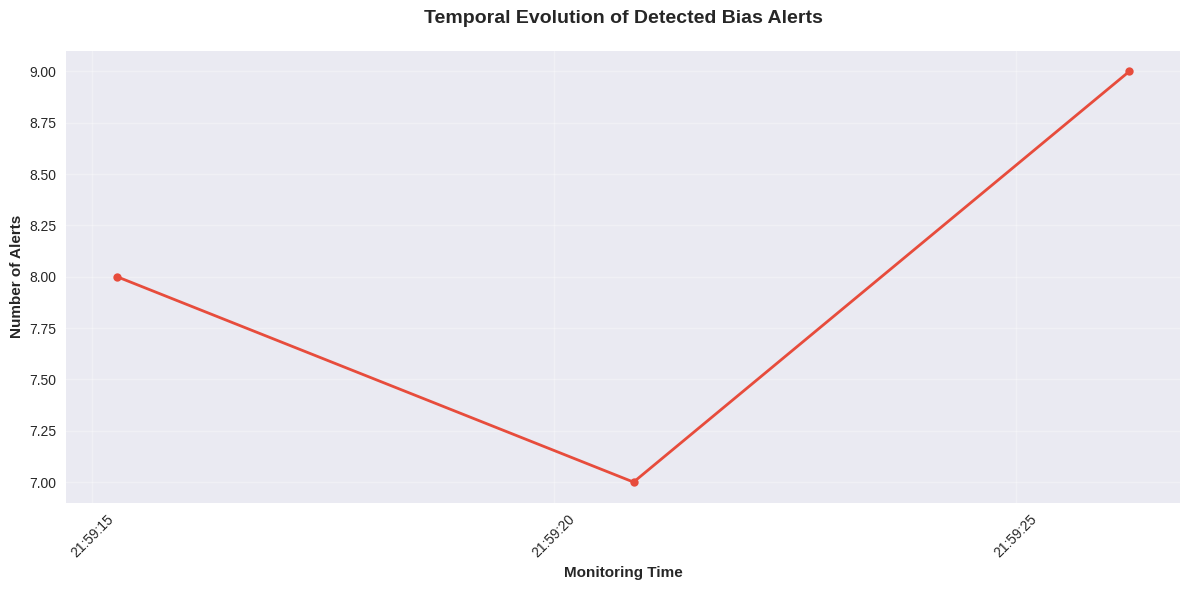

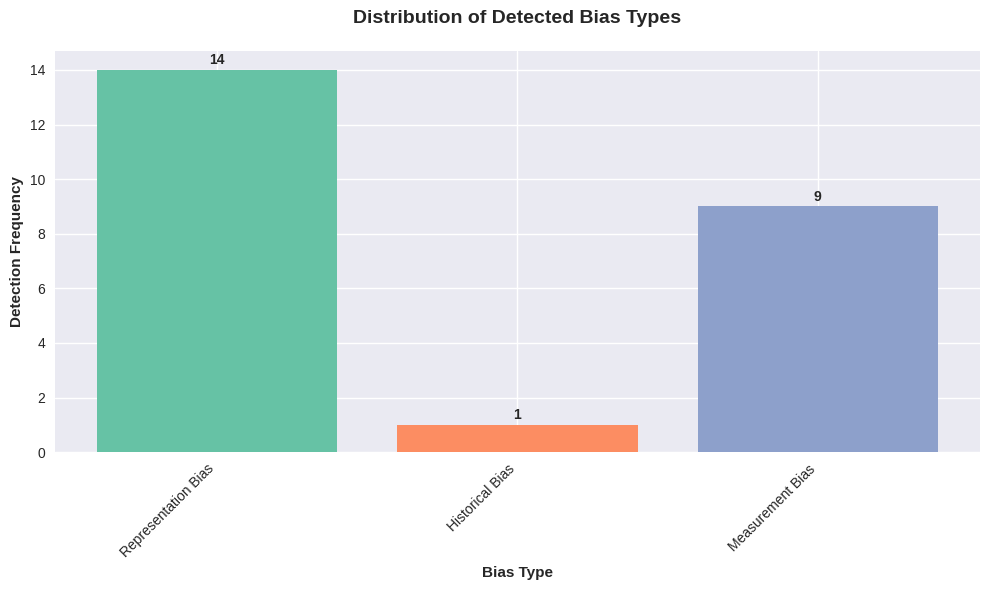

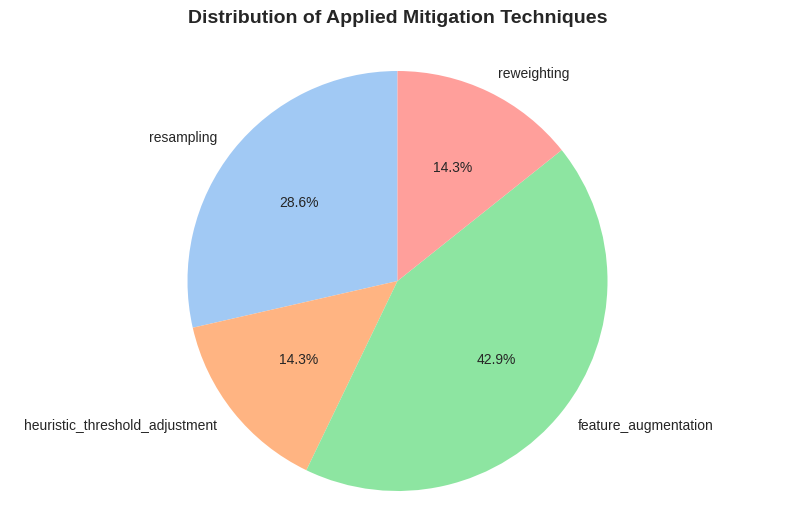

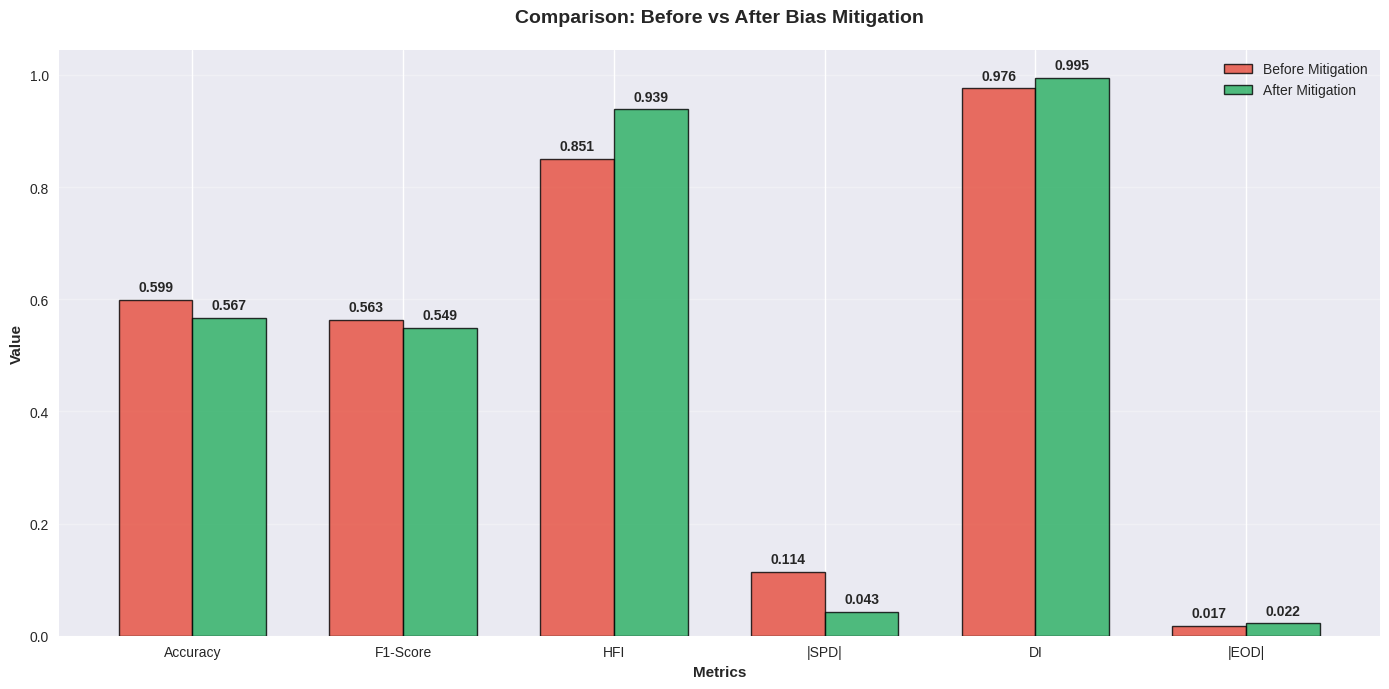

In [55]:
def main():
    """
    Main function that executes the complete bias detection and mitigation system for the COMPAS dataset.
    """
    print("Starting Intersectional Bias Detection and Mitigation System...")
    print("=" * 60)

    # -------------------------------------------------------------------------
    # 1. DATASET DEFINITION
    # -------------------------------------------------------------------------
    DATASET_TO_RUN = 'compas'
    # -------------------------------------------------------------------------
    # 2. Initialize the integrated system
    # -------------------------------------------------------------------------
    system = BiasMitigationSystem()

    try:
        system.initialize_system(dataset_name=DATASET_TO_RUN)
    except ValueError as e:
        print(f"ERROR: {e}")
        return

    print("-" * 60)

    # -------------------------------------------------------------------------
    # 3. Execute complete monitoring cycle
    # -------------------------------------------------------------------------

    NUM_PREDICTIONS = 600
    print(f"Simulating monitoring cycle with {NUM_PREDICTIONS} predictions...")
    alerts, decisions = system.run_complete_monitoring(num_predictions=NUM_PREDICTIONS)

    # -------------------------------------------------------------------------
    # 4. Generate final report with complete analysis
    # -------------------------------------------------------------------------
    system.generate_report(alerts, decisions)

if __name__ == "__main__":
    main()